# Packages

In [ ]:
# for colab, install dependencies
!pip install "jax==0.7.2" "jaxlib==0.7.2" "diffrax==0.7.0" "equinox" "optax"


In [ ]:
import jax
import jax.numpy as jnp
from jax import jit, vmap, lax
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from tqdm.auto import tqdm
import optax

jax.config.update("jax_enable_x64", True)

# ---------- Colab-friendly import of shared Dynamics/Training modules ----------
import os, sys

REPO_URL = "https://github.com/YanchengDu/LiquidCHL.git"
REPO_DIR = "LiquidCHL"

if os.path.isdir("Dynamics") and os.path.isdir("Training"):
    repo_root = "."
elif os.path.isdir(os.path.join("..", "Dynamics")):
    repo_root = ".."
else:
    if not os.path.isdir(REPO_DIR):
        !git clone {REPO_URL} {REPO_DIR}
    repo_root = REPO_DIR

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Dynamics.Model_A import forward_sim_x_ssolvent_clamp, x_to_phi


In [14]:
# ---------- Shared config: dynamics (training + testing) and training hyperparameters ----------
# Use these in one place so training and testing stay consistent.
from random import randint


DT_DYNAMICS = 1e-1
MAX_STEPS = 30_000
T_END = 300.0  # Integration end time (used by training and testing)

# Training hyperparameters (used by CHL_training_hidden / daydreaming)
GAMMA_LEARNING = 0.02
N_SAMPLE = 3000
# Seed for training (set to an int for reproducibility, or None for random)
TRAINING_SEED = randint(0,1000)
# Model / run layout (used by training cells and parameter sweep)
N_SPECIES = 100

In [3]:
# Check if JAX sees GPU
print("JAX version:", jax.__version__)
print("Default backend:", jax.default_backend())
print("Visible devices:", jax.devices())
for i, d in enumerate(jax.devices()):
    print(f"  [{i}] {d.device_kind} (id={d.id})")
# Quick sanity check: run a tiny op and see where it runs
x = jnp.ones((3, 3))
print("\nSample array device:", x.devices())
print("GPU in use:", jax.default_backend() == "gpu")

JAX version: 0.7.2
Default backend: gpu
Visible devices: [CudaDevice(id=0)]
  [0] NVIDIA A100-SXM4-40GB (id=0)

Sample array device: {CudaDevice(id=0)}
GPU in use: True


# Set up training with MNIST training

In [6]:
# load the MNIST data for classification
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
# Normalize pixel values to [0, 1]
# Normalize by soft max
# train_images = np.exp(train_images / 1.0)
# train_images = train_images / np.sum(train_images, axis=(1, 2), keepdims=True)
# test_images = np.exp(test_images / 1.0)
# test_images = test_images / np.sum(test_images, axis=(1, 2), keepdims=True)
train_images = train_images / 255.0
test_images = test_images / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


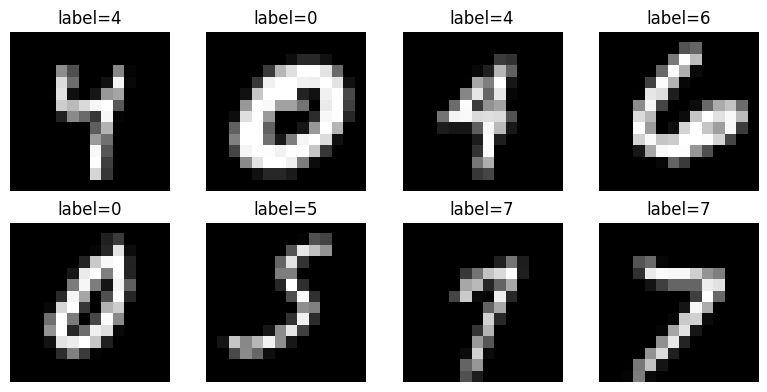

In [7]:
def downsample_avg(images, out_h=7, out_w=7):
    images = np.asarray(images)
    n, h, w = images.shape
    assert h % out_h == 0 and w % out_w == 0, "Input size must be divisible by output size"
    hf, wf = h // out_h, w // out_w
    return images.reshape(n, out_h, hf, out_w, wf).mean(axis=(2, 4))

# create 14x14 downsized versions (doesn't overwrite existing variables)
train_ds14 = downsample_avg(train_images, 14, 14)
test_ds14 = downsample_avg(test_images, 14, 14)

# plot some samples
rng = np.random.default_rng(TRAINING_SEED)
idx = rng.choice(len(train_ds14), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ax, i in zip(axes.flat, idx):
    ax.imshow(train_ds14[i], cmap="gray", interpolation="nearest")
    ax.set_title(f"label={train_labels[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

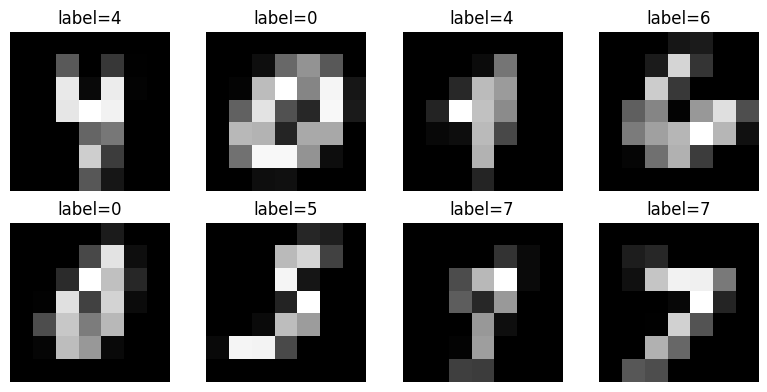

In [8]:
def downsample_avg(images, out_h=7, out_w=7):
    images = np.asarray(images)
    n, h, w = images.shape
    assert h % out_h == 0 and w % out_w == 0, "Input size must be divisible by output size"
    hf, wf = h // out_h, w // out_w
    return images.reshape(n, out_h, hf, out_w, wf).mean(axis=(2, 4))

# create 7x7 downsized versions (doesn't overwrite existing variables)
train_ds7 = downsample_avg(train_images, 7, 7)
test_ds7 = downsample_avg(test_images, 7, 7)

# plot some samples
rng = np.random.default_rng(TRAINING_SEED)
idx = rng.choice(len(train_ds7), size=8, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for ax, i in zip(axes.flat, idx):
    ax.imshow(train_ds7[i], cmap="gray")#, vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"label={train_labels[i]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Setup training on the MNIST data

In [9]:
# create target memories: [input(49), output(10), hidden(N_hidden), solvent(1)]
N_input = 49
N_output = 10
N_solvent = 1
N_hidden = N_SPECIES - (N_input + N_output + N_solvent)
N_clamped = N_input + N_output
assert N_hidden > 0, "N_hidden must be positive. Adjust N_SPECIES or component sizes."

def make_target_memories(images, labels):
    images = np.asarray(images)
    idx = np.arange(len(images))

    mems = []
    for i in idx:
        inp = images[i].ravel().astype(float) / N_SPECIES * 3.0  # 49 elements
        out = np.ones(N_output, dtype=float) * 0.25 / N_SPECIES * 1.0
        out[labels[i]] = 1.1 / N_SPECIES * 1.0             # one-hot output (10)
        hidden = (1.0 / N_SPECIES + np.random.random(N_hidden) * 0.01 / N_SPECIES) * 1.0   # small positive hidden activity
        solvent = np.array([1.0 - np.sum(np.concatenate([inp, out, hidden]))], dtype=float)  # small solvent element

        vec = np.concatenate([inp, out, hidden, solvent])
        vec = np.clip(vec, 1e-8, None)
        vec = vec / vec.sum()                    # make compositional (sum to 1)
        mems.append(vec)

    return np.stack(mems)

# example: create all as target memories from the 7x7 training set
target_memories = make_target_memories(train_ds7, train_labels)

# check that target memories are compositional and have the expected shape
print("Target memories shape:", target_memories.shape)  # should be (N_SAMPLE, N_SPECIES)
# check if all sum to 1
sums = target_memories.sum(axis=1)
print("Sum of components (should be 1):", sums[:10])  # print first 10 sums to check
# print some example target memories
for i in range(3):
    print(f"Target memory {i}:")
    print("  Input (first 49):", target_memories[i][:N_input])
    print("  Output (next 10):", target_memories[i][N_input:N_input+N_output])
    print("  Hidden (next N_hidden):", target_memories[i][N_input+N_output:N_input+N_output+N_hidden])
    print("  Solvent (last element):", target_memories[i][-1])

Target memories shape: (60000, 100)
Sum of components (should be 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Target memory 0:
  Input (first 49): [9.99999720e-09 9.99999720e-09 9.99999720e-09 9.99999720e-09
 9.99999720e-09 9.99999720e-09 9.99999720e-09 9.99999720e-09
 3.60294017e-04 9.63970318e-03 1.46911724e-02 1.50367605e-02
 1.26911729e-02 9.99999720e-09 9.99999720e-09 1.32352904e-04
 1.38382314e-02 1.57573485e-02 5.03676330e-03 9.99999720e-09
 9.99999720e-09 9.99999720e-09 9.99999720e-09 8.08823303e-05
 1.45514665e-02 8.74264461e-03 9.99999720e-09 9.99999720e-09
 9.99999720e-09 9.99999720e-09 9.99999720e-09 6.33088058e-03
 2.47794048e-02 4.85293982e-04 9.99999720e-09 9.99999720e-09
 6.58088051e-03 1.96617592e-02 1.92499946e-02 4.52205756e-03
 9.99999720e-09 9.99999720e-09 9.99999720e-09 6.58088051e-03
 3.63970486e-03 9.99999720e-09 9.99999720e-09 9.99999720e-09
 9.99999720e-09]
  Output (next 10): [0.0025 0.0025 0.0025 0.0025 0.0025 0.011  0.0025 0.0025 0.0025 0.0025]
  Hidden (next N_hidd

In [ ]:
import time

def daydreaming_contrastive_hebbian_learning_lagrange_JAX_fast_sample_adamw(
    target_memories, chi_initial, miu_initial,
    V=1.0, gamma_dynamics=1.0, dt_dynamics=1e-2, n_steps_dynamics=30000,
    gamma_learning=10.0, n_epochs=200, clamped=None,
    n_sample=None, t_end=None,
    p_boundary_schedule=None,
    weight_decay=1e-5,
    print_energy=True, key_seed=42
):
    if t_end is None: t_end = T_END

    target_memories = jnp.array(target_memories)
    chi_initial = jnp.array(chi_initial)
    miu_initial = jnp.array(miu_initial)

    @jit
    def flory_huggins_free_energy_jax(phi, chi, miu, V):
        phi = jnp.clip(phi, 1e-10, 1.0)
        entropy = jnp.sum(phi * jnp.log(phi))
        interaction = 0.5 * phi @ chi @ phi
        potential = jnp.sum(miu * phi)
        return V * (entropy + interaction + potential)

    # ---------------- Single Memory Update ----------------
    def update_chi_single(key, phi, chi, miu, V, gamma_dynamics, dt_dynamics,
                          n_steps_dynamics, clamped=None):
        N = phi.shape[0]
        # Positive phase
        phi_ini = jax.random.normal(key, shape=phi.shape) * 0.1 * 1 / N + 1 / N
        phi_ini = phi_ini.at[:clamped].set(phi[:clamped])
        phi_ini = jnp.clip(phi_ini, 1e-8, 1.0)
        sum_fixed = jnp.sum(phi_ini[:clamped])
        sum_rem = jnp.sum(phi_ini[clamped:])
        phi_ini = phi_ini.at[clamped:].set(phi_ini[clamped:] / sum_rem * (1 - sum_fixed))
        phi_plus_diffrax = forward_sim_x_ssolvent_clamp(
            phi0 = phi_ini,
            chi = chi,
            mu = miu,
            clamp = clamped,
            t_end = t_end,
            dt = dt_dynamics,
            samples=10,
            max_steps=n_steps_dynamics,
        )
        phi_plus = x_to_phi(phi_plus_diffrax.ys[-1])

        # Negative phase
        phi_minus_diffrax = forward_sim_x_ssolvent_clamp(
            phi0 = phi_plus,
            chi = chi,
            mu = miu,
            clamp = N_input,  # only clamp the input for the negative phase
            t_end = t_end,
            dt = dt_dynamics,
            samples=10,
            max_steps=n_steps_dynamics,
        )
        phi_minus = x_to_phi(phi_minus_diffrax.ys[-1])

        # Energy

        F_plus = flory_huggins_free_energy_jax(phi_plus, chi, miu, V)
        F_minus = flory_huggins_free_energy_jax(phi_minus, chi, miu, V)
        energy_diff = F_plus - F_minus

        def compute_true_error_swap(phi_ini, phi_minus, N):
            pred = phi_ini[2] > phi_ini[3]

            i_hi = jnp.where(pred, 2, 3)
            i_lo = jnp.where(pred, 3, 2)

            return (
                jnp.log(1 + N * jnp.maximum(1.1 / N - phi_minus[i_hi], 0.0)) +
                jnp.log(1 + N * jnp.minimum(phi_minus[i_lo] - 0.25 / N, 0.0))
            )

        # Gradients (for AdaGrad)
        true_error = compute_true_error_swap(phi_ini, phi_minus, N)
        grad_scaling = 1.0
        grad_chi = (jnp.outer(phi_plus, phi_plus) - jnp.outer(phi_minus, phi_minus)) * grad_scaling
        grad_miu = (phi_plus - phi_minus) * grad_scaling

        # Zero out fixed elements
        grad_chi = grad_chi.at[jnp.diag_indices(grad_chi.shape[0])].set(0.0)
        grad_miu = grad_miu.at[:N_input].set(0.0)
        grad_miu = grad_miu.at[-1].set(0.0)  # solvent potential should not change
        # zero out last row and column
        grad_chi = grad_chi.at[-1,:].set(0.0)
        grad_chi = grad_chi.at[:,-1].set(0.0)
        # zero out input element
        grad_chi = grad_chi.at[:N_input,:N_input].set(0.0)

        return grad_chi, grad_miu, energy_diff, true_error

    # ---------------- AdamW optimizer ----------------
    params = (chi_initial, miu_initial)
    optimizer = optax.adamw(learning_rate=gamma_learning, weight_decay=weight_decay)
    opt_state = optimizer.init(params)

    # ---------------- Batched Update (only use target_memories) ----------------
    def batched_update(key, chi, miu, opt_state, clamped):
        if target_memories is None:
            raise ValueError("target_memories must be provided; random-memory generation disabled.")
        sample_size = n_sample if n_sample is not None else target_memories.shape[0]

        # sample from provided target_memories (with replacement if needed)
        num_memories = target_memories.shape[0]
        key, subkey = jax.random.split(key)
        replace = sample_size > num_memories
        indices = jax.random.choice(subkey, num_memories, (sample_size,), replace=replace)
        sampled_memories = target_memories[indices]

        mem_keys = jax.random.split(key, sample_size + 1)
        key = mem_keys[0]
        mem_keys = mem_keys[1:]

        grad_chi_list, grad_miu_list, energy_diffs, true_errors = jax.vmap(
            lambda k, mem: update_chi_single(k, mem, chi, miu, V, gamma_dynamics, dt_dynamics, n_steps_dynamics, clamped)
        )(mem_keys, sampled_memories)

        grad_chi = jnp.mean(grad_chi_list, axis=0)
        grad_miu = jnp.mean(grad_miu_list, axis=0)

        avg_energy_diff = jnp.mean(energy_diffs)
        avg_true_error = jnp.mean(true_errors)

        # AdamW step (optax convention: grads are for a loss we minimize)
        grads = (grad_chi, grad_miu)
        updates, opt_state = optimizer.update(grads, opt_state, (chi, miu))
        chi_new, miu_new = optax.apply_updates((chi, miu), updates)

        # Clip chi to [-25, 25]
        chi_new = jnp.clip(chi_new, -25.0, 25.0)
        

        return key, chi_new, miu_new, opt_state, avg_energy_diff, avg_true_error

    # ---------------- Training Loop ----------------
    key = jax.random.PRNGKey(key_seed)

    t0 = time.time()
    energy_history = []
    true_error_history = []
    chi, miu = chi_initial, miu_initial

    pbar = tqdm(range(n_epochs), desc="Training", unit="epoch")

    for epoch in pbar:
        key, chi, miu, opt_state, avg_E, avg_true_error = batched_update(key, chi, miu, opt_state, clamped)
        energy_history.append(avg_E)
        true_error_history.append(avg_true_error)
        if print_energy:
            #tqdm.write(f"Epoch {epoch+1}/{n_epochs}, Avg Energy Diff = {avg_E:.6f}")
            pbar.set_postfix({ "Avg Energy Diff": f"{avg_E:.6f}", "Avg True Error": f"{avg_true_error:.6f}" })

    t1 = time.time()
    if print_energy:
        print(f"Total training time: {t1 - t0:.3f} s")

    return chi, miu, energy_history, true_error_history

In [11]:
def evaluate_and_plot_training(
    chi_learned, miu_learned,
    forward_sim_x_ssolvent_clamp,
    energy_diff_hist=None,
    true_error_hist=None,
    clamped=N_clamped,
    n_points=1000,
    dt_dynamics=None,
    max_steps=None,
    t_end=None,
    key_seed=0,
    plot=True,
    n_examples=8,
):
    if dt_dynamics is None: dt_dynamics = DT_DYNAMICS
    if max_steps is None: max_steps = MAX_STEPS
    if t_end is None: t_end = T_END

    # ----- 1. Training curve summary -----
    if plot and energy_diff_hist is not None and true_error_hist is not None:
        energy_hist = np.array(energy_diff_hist)
        error_hist = np.array(true_error_hist)
        print("=== Training summary ===")
        print(f"  Energy diff (F+ - F-):  initial = {energy_hist[0]:.6f},  final = {energy_hist[-1]:.6f}")
        print(f"  True error (swap loss):  initial = {error_hist[0]:.6f},  final = {error_hist[-1]:.6f}")
        if len(energy_hist) > 1:
            print(f"  Energy trend: {'↓' if energy_hist[-1] < energy_hist[0] else '↑'}  (min = {energy_hist.min():.6f})")
        if len(error_hist) > 1:
            print(f"  Error trend:  {'↓' if error_hist[-1] < error_hist[0] else '↑'}  (min = {error_hist.min():.6f})")
        print()

    # Prepare test set (use downsized 7x7 images and labels already in notebook)
    n_available = len(test_ds7)
    n_test = min(n_points, n_available)
    rng = np.random.default_rng(key_seed)
    idx = rng.choice(n_available, size=n_test, replace=False)

    images = test_ds7[idx]  # shape (n_test,7,7)
    labels = test_labels[idx]

    # build full compositional phi0 vectors from images
    def make_phi_from_image(img):
        inp = np.asarray(img).ravel().astype(float) / N_SPECIES  # length N_input
        out = 1.0 / N_SPECIES + np.random.random(N_output) * 0.01 / N_SPECIES  # length N_output
        hidden = 1.0 / N_SPECIES + np.random.random(N_hidden) * 0.01 / N_SPECIES    # small positive hidden activity
        solvent = np.array([1.0 - np.sum(np.concatenate([inp, out, hidden]))], dtype=float)
        vec = np.concatenate([inp, out, hidden, solvent])
        vec = np.clip(vec, 1e-8, None)
        vec = vec / vec.sum()
        return vec

    phis0 = jnp.array(np.stack([make_phi_from_image(im) for im in images]))

    # simulate batched
    simulate_batched = jax.vmap(
        lambda phi0: x_to_phi(forward_sim_x_ssolvent_clamp(
            phi0=phi0, chi=chi_learned, mu=miu_learned, clamp=clamped,
            t_end=t_end, dt=dt_dynamics, samples=10, max_steps=max_steps,
        ).ys[-1])
    )
    outputs = simulate_batched(phis0)
    if hasattr(outputs, "block_until_ready"):
        outputs.block_until_ready()
    outputs_np = np.array(outputs)
    out_slice = outputs_np[:, N_input:N_input+N_output]

    # predicted class = index of largest output
    pred_class = np.argmax(out_slice, axis=1)
    accuracy = np.mean(pred_class == labels)

    if plot:
        print("=== Test accuracy (largest output correctness) ===")
        print(f"  Overall accuracy: {accuracy*100:.2f}%  ({int(np.round(accuracy*n_test))}/{n_test} correct)")
        # show a few example classification results
        example_idx = rng.choice(n_test, size=min(n_examples, n_test), replace=False)
        fig, axes = plt.subplots(len(example_idx), 2, figsize=(6, 3*len(example_idx)), constrained_layout=True)
        axes = np.atleast_2d(axes)
        for row, ii in enumerate(example_idx):
            ax_img = axes[row, 0]
            ax_bar = axes[row, 1]
            ax_img.imshow(images[ii], cmap="gray", vmin=0, vmax=1)
            ax_img.axis("off")
            ax_img.set_title(f"true={int(labels[ii])}  pred={int(pred_class[ii])}")
            ax_bar.bar(np.arange(N_output), out_slice[ii])
            ax_bar.set_xlabel("output node")
            ax_bar.set_ylabel("phi (final)")
            ax_bar.set_ylim(0, out_slice.max()*1.1 if out_slice.size>0 else 1.0)
        plt.show()

    eval_metrics = {
        "accuracy": float(accuracy),
        "n_test": int(n_test),
    }
    results = {
        "indices": idx,
        "pred_class": np.array(pred_class),
        "true_class": np.array(labels),
        "output_slice": out_slice,
    }
    return eval_metrics, results, outputs_np

In [13]:
def CHL_training_hidden(target_memories, n_species, n_epochs, clamped=N_clamped, train_more=False,
                  gamma_learning=None, n_sample=None, dt_dynamics=None, max_steps=None, t_end=None, verbose=True, seed=None):
    global chi_learned
    global miu_learned
    # Use config defaults when not provided
    if gamma_learning is None: gamma_learning = GAMMA_LEARNING
    if n_sample is None: n_sample = N_SAMPLE
    if dt_dynamics is None: dt_dynamics = DT_DYNAMICS
    if max_steps is None: max_steps = MAX_STEPS
    if t_end is None: t_end = T_END

    if seed is None: seed = np.random.randint(0, 1000)
    if verbose: print("seed:", seed)

    rng = np.random.default_rng(seed)

    chi_initial = rng.uniform(low=-15.0, high=15.0, size=(n_species, n_species))
    chi_initial[:N_clamped, :N_clamped] = rng.normal(loc=0.0, size=(N_clamped, N_clamped)) * 0.1
    chi_initial = (chi_initial + chi_initial.T) / 2
    np.fill_diagonal(chi_initial, 0.0)
    chi_initial[-1,:] = 0.0
    chi_initial[:,-1] = 0.0
    chi_initial[:N_input,:N_input] = 0.0
    if train_more:
        chi_initial = chi_learned

    if verbose:
        plt.figure(figsize=(8, 5))
        plt.imshow(chi_initial, cmap='coolwarm', interpolation='nearest', vmin=-np.max(np.abs(chi_initial)), vmax=np.max(np.abs(chi_initial)))
        plt.colorbar()
        plt.title('Initial Interaction Matrix')
        plt.show()

    miu_initial = rng.normal(loc=0.0, size=(n_species)) * 0.0
    if train_more:
        miu_initial = miu_learned

    # Call the training routine with matched argument names
    chi_learned, miu_learned, energy_diff_hist, true_error_hist = daydreaming_contrastive_hebbian_learning_lagrange_JAX_fast_sample_adamw(
        target_memories=target_memories,
        chi_initial=chi_initial,
        miu_initial=miu_initial,
        V=1.0,
        gamma_dynamics=1.0,
        dt_dynamics=dt_dynamics,
        n_steps_dynamics=max_steps,
        gamma_learning=gamma_learning,
        n_epochs=n_epochs,
        clamped=clamped,
        n_sample=n_sample,
        t_end=t_end,
        weight_decay=1e-5,
        print_energy=True,
        key_seed=seed,
    )

    if verbose:
        plt.figure(figsize=(8, 5))
        plt.imshow(chi_learned, cmap='coolwarm', interpolation='nearest', vmin=-np.max(np.abs(chi_learned)), vmax=np.max(np.abs(chi_learned)))
        plt.colorbar()
        plt.title('Learned Interaction Matrix')
        plt.show()
        chi_change = chi_learned - chi_initial
        plt.figure(figsize=(8, 5))
        plt.imshow(chi_change, cmap='coolwarm', interpolation='nearest',vmin=-np.max(np.abs(chi_change)), vmax=np.max(np.abs(chi_change)))
        plt.colorbar()
        plt.title('Change in Interaction Matrix')
        plt.show()

    def plot_grayscale_blocks(values, orientation='horizontal', cmap='gray', figsize=(8,1), vmin=None, vmax=None, show_colorbar=False):
        """
        Plot a 1D list/array `values` as adjacent grayscale blocks.
        orientation: 'horizontal' (1 x n) or 'vertical' (n x 1)
        """
        arr = np.asarray(values, dtype=float)
        if vmin is None: vmin = np.nanmin(arr)
        if vmax is None: vmax = np.nanmax(arr)
        if orientation == 'horizontal':
            im = arr.reshape(1, -1)
            fig, ax = plt.subplots(figsize=figsize)
            mappable = ax.imshow(im, cmap=cmap, aspect='auto', interpolation='nearest', vmin=vmin, vmax=vmax)
            ax.set_yticks([]); ax.set_xticks([])
        else:
            im = arr.reshape(-1, 1)
            fig, ax = plt.subplots(figsize=(figsize[1], figsize[0]) if isinstance(figsize, tuple) else (1, len(arr)/4))
            mappable = ax.imshow(im, cmap=cmap, aspect='auto', interpolation='nearest', vmin=vmin, vmax=vmax)
            ax.set_xticks([]); ax.set_yticks([])

        if show_colorbar:
            plt.colorbar(mappable=mappable, ax=ax, orientation='horizontal' if orientation=='horizontal' else 'vertical')
        plt.tight_layout()
        plt.show()

    if verbose:
        plot_grayscale_blocks(miu_learned, orientation='horizontal', figsize=(chi_learned.shape[0], 1.0), show_colorbar=True)
        plt.figure(figsize=(8, 5))
        plt.plot(energy_diff_hist)
        plt.xlabel('Epoch')
        plt.ylabel('Average Energy Difference (F+ - F-)')
        plt.title('Contrastive Hebbian Learning Progress')
        plt.grid(True)
        plt.show()
        plt.figure(figsize=(8, 5))
        plt.plot(true_error_hist)
        plt.xlabel('Epoch')
        plt.ylabel('Average True Error')
        plt.title('Contrastive Hebbian Learning Progress')
        plt.grid(True)
        plt.show()
        print("chi_learned:", chi_learned)
        print("miu_learned:", miu_learned)
    return chi_learned, miu_learned, energy_diff_hist, true_error_hist

# Training again lr = 0.05

seed: 161


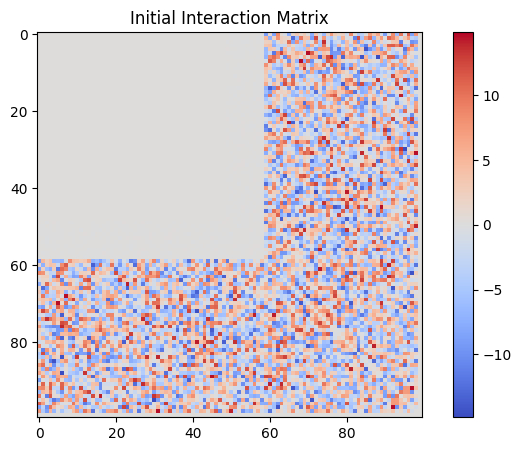

Training:   0%|          | 0/1000 [00:00<?, ?epoch/s]

Total training time: 2616.345 s


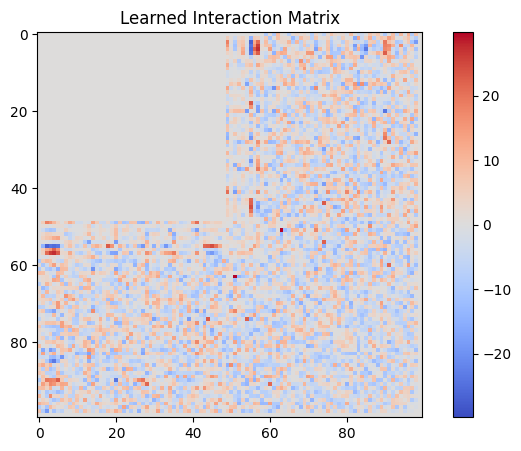

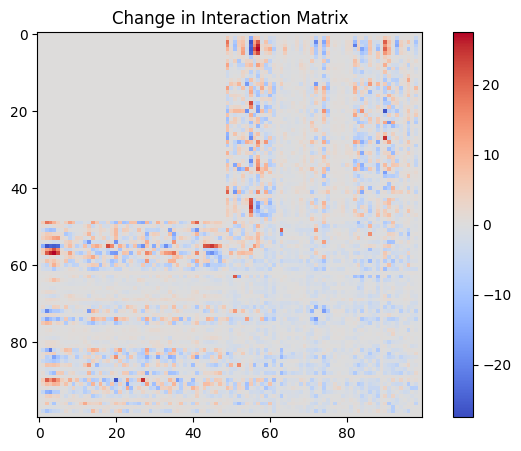

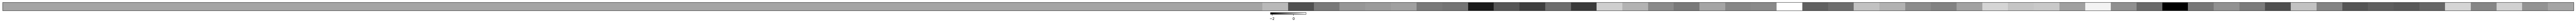

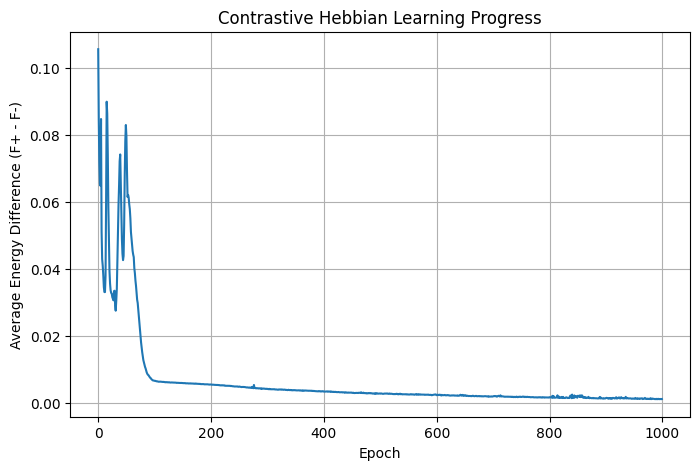

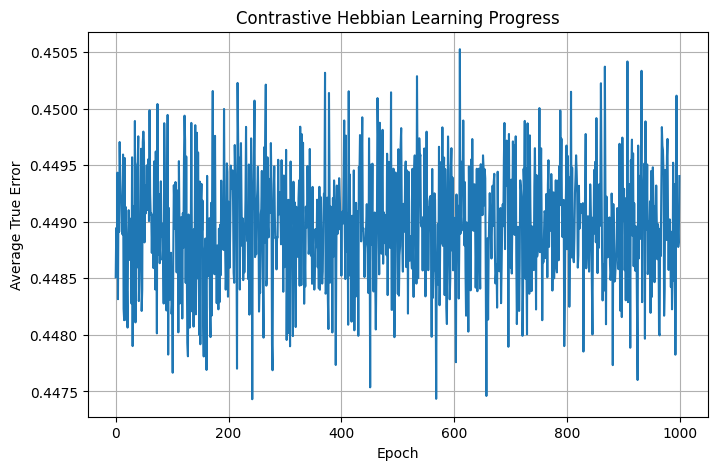

chi_learned: [[  0.           0.           0.         ...  -8.20718516   7.51513447
    0.        ]
 [  0.           0.           0.         ...  -2.97808241  -8.36078628
    0.        ]
 [  0.           0.           0.         ... -10.16277571 -18.29950129
    0.        ]
 ...
 [ -8.20718516  -2.97808241 -10.16277571 ...   0.          -1.32585363
    0.        ]
 [  7.51513447  -8.36078628 -18.29950129 ...  -1.32585363   0.
    0.        ]
 [  0.           0.           0.         ...   0.           0.
    0.        ]]
miu_learned: [-0.          0.          0.         -0.          0.          0.
 -0.         -0.          0.          0.         -0.          0.
  0.          0.          0.         -0.          0.          0.
  0.         -0.         -0.          0.          0.         -0.
 -0.          0.         -0.          0.         -0.         -0.
 -0.         -0.         -0.          0.          0.          0.
  0.          0.          0.         -0.         -0.         -0.
  0.   

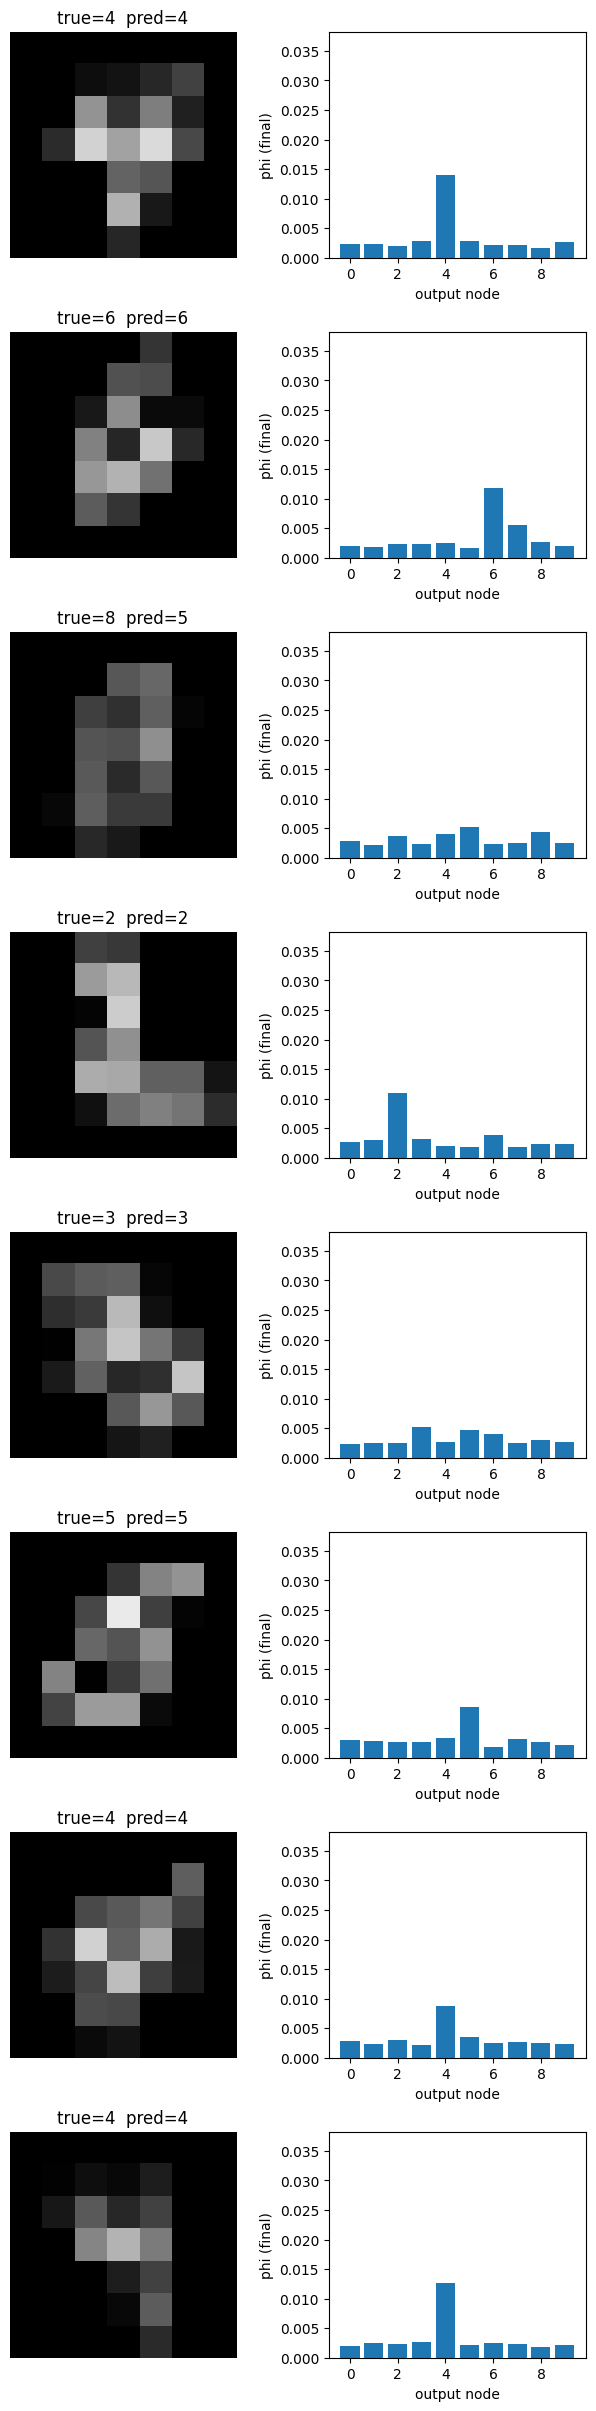

({'accuracy': 0.755, 'n_test': 1000},
 {'indices': array([8644, 8982,  525, 4319, 1821, 2848, 8700, 7583, 8569, 6962,  203,
         1961, 4697, 4054, 5194, 9684, 3267, 6357, 7021, 6215, 2146, 7460,
          769, 8035, 7770, 1538, 5647, 2390,  830, 8575, 3189, 2990, 3065,
         2695, 8893,  283, 9950,  778, 8934, 9464,  178,  788, 9287, 3935,
         5849, 5598, 5517, 5199, 3867, 5377, 1817, 5864, 9336, 5435,  510,
         7600, 4515, 1916, 7139, 7425, 7053, 1325, 4977, 8154, 7294, 6106,
         4809, 2065, 9351, 8214, 8758, 8392, 3607, 6903, 6229,  669, 6101,
         5760,  285, 9451, 1571, 2888, 9877, 5226, 3345, 5617, 3331, 8224,
         6235, 2613, 8542, 7448, 7282, 9619, 7070, 4721, 8821, 8638,  701,
         1638,  895, 4533, 9064, 3549, 2308, 3053, 1601, 7620, 3578, 5203,
         7957, 8539, 1810, 4784, 2825, 1697, 9812, 3963, 5570, 8953, 9648,
         4094, 1730, 5873, 9004,  511, 4667,   56, 5713, 6369, 9065, 7940,
         5829, 5761, 3516, 4776, 3319, 8508, 1944, 

In [15]:
chi_learned, miu_learned, energy_diff_hist, true_error_hist = CHL_training_hidden(
    target_memories=target_memories, n_species=N_SPECIES, n_epochs=1000, clamped=N_clamped, train_more=False, 
    seed=TRAINING_SEED, 
)

# Single sampling: evaluation + scatter plots (saves running forward sim twice)
evaluate_and_plot_training(
    chi_learned, miu_learned,
    forward_sim_x_ssolvent_clamp,
    energy_diff_hist=energy_diff_hist,
    true_error_hist=true_error_hist,
    clamped=N_input,
    n_points=1000,
    key_seed=TRAINING_SEED if TRAINING_SEED is not None else 0,
    plot=True,
    n_examples=8,
)